In [ ]:
import json
import operator
import io
import sys
import traceback
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, Optional, Literal, Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph import StateGraph, END, START
from langchain_community.tools import DuckDuckGoSearchRun
from pypdf import PdfReader
from pathlib import Path

load_dotenv()

C:\Users\YeXiaoJun\AppData\Local\Temp\ipykernel_24016\1034655981.py:18: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


False

In [2]:
model = ChatOpenAI(model="gpt-4o", temperature=0)

In [3]:
class OverAllState(TypedDict):
    messages_history: Annotated[List[BaseMessage], operator.add]
    thesis_topic: str 
    request_type: str
    user_query: str
    output: str
    
@tool
def web_search(query: str) -> str: # can use pydantic instead of args and returns
    """
    Searches the web for up-to-date information, papers, or documentation.
    
    Args:
        query: user input
    Returns:
        A formatted string of snippet results or an error description.
    """
    try:
        search = DuckDuckGoSearchRun()
        return search.invoke(query)
    except Exception as e:
        return f"Search error: {e}"
    
@tool
def file_reader(file_path: str) -> str: # to be replaced/extended with RAG
    """
    Reads the content of a local file (supports .txt, .md, .py, .json, and .pdf).
    
    Args:
        file_path: destination of the file to be read
    Returns:
        Return what is read
    """
    path = Path(file_path)
    if not path.exists():
        return f"Error: File '{file_path}' does not exist."
    
    try:
        if path.suffix.lower() == ".pdf":
            reader = PdfReader(file_path)
            return "\n".join([page.extract_text() or "" for page in reader.pages])
        return path.read_text(encoding="utf-8")
    except Exception as e:
        return f"Error reading '{file_path}': {e}"

class GeneratedCode(BaseModel):
    code: str = Field(description="Raw executable Python code with no markdown formatting.")

@tool
def code_generator(prompt: str) -> str:
    """Generates clean, runnable Python code based on a task description (math tasks).
    Outputs the raw code string to be passed to python_executor.
    """
    code_model = model.with_structured_output(GeneratedCode)
    system_prompt = (
        "You are an expert Python developer. Write clean, complete, executable Python code. "
        "Always make sure to print results to stdout using print()."
    )
    result = code_model.invoke(f"{system_prompt}\n\nTask: {prompt}")
    return result.code

@tool
def python_executor(code: str) -> str:
    """Executes arbitrary Python code and returns the stdout or error traceback."""
    old_stdout = sys.stdout
    redirected_output = io.StringIO()
    sys.stdout = redirected_output
    
    exec_globals = {}
    try:
        exec(code, exec_globals)
        output = redirected_output.getvalue()
        return output.strip() if output.strip() else "Execution successful (no output)."
    except Exception:
        return f"Execution Error:\n{traceback.format_exc()}"
    finally:
        sys.stdout = old_stdout
        
        
tools = [web_search, file_reader, code_generator, python_executor]
model_with_tools = model.bind_tools(tools)

In [ ]:
class SupervisorDecision(BaseModel):
    next_step: Literal["research_node", "write_node"] = Field(
        description="Choose 'research_node' if the task requires web search, files, code execution, or analysis. Choose 'write_node' for direct drafting/editing."
    )

class ReviewDecision(BaseModel):
    next_step: Literal["approved", "needs_more_research", "needs_revision"] = Field(
        description="Select 'approved' to finish, 'needs_more_research' if data/facts are missing, or 'needs_revision' for writing/style fixes."
    )
    feedback: str = Field(
        default="",
        description="Actionable critique explaining what to fix or research."
    )

In [11]:
def supervisor_router(state: OverAllState) -> str:
    router_model = model.with_structured_output(SupervisorDecision)
    decision = router_model.invoke(
        f"Route this user query to the best worker:\n{state['user_query']}"
    )
    return decision.next_step

def research_router(state: OverAllState) -> Literal["tool_node", "write_node"]:
    """
    Checks if the last message in research_node generated tool calls.
    - If yes -> route to 'tool_node' to execute the tools.
    - If no  -> research is done, route directly to 'write_node'.
    """
    messages = state.get("messages_history", [])
    if not messages:
        return "write_node"
        
    last_message = messages[-1]
    
    if getattr(last_message, "tool_calls", None):
        return "tool_node"
        
    return "write_node"

def reviewer_router(state: OverAllState) -> Literal["research_node", "write_node", "__end__"]:
    status = state.get("request_type")
    
    if status == "needs_more_research":
        return "research_node"
    elif status == "needs_revision":
        return "write_node"
    return END

In [ ]:
def research_node(state: OverAllState) -> dict:
    """Autonomous research agent with search, reading, and execution tools."""
    system_prompt = SystemMessage(content=(
        "You are an expert research analyst. Use your available tools (web_search, file_reader, "
        "code_generator, python_executor) to gather all necessary facts, analyze papers, or run calculations. "
        "When you have completed all research, synthesize your findings into comprehensive notes."
    ))
    messages = [system_prompt] + state.get("messages_history", [])
    response = model_with_tools.invoke(messages)
    
    return {
        "messages_history": [response],
        "output": response.content if isinstance(response.content, str) else ""
    }

def write_node(state: OverAllState) -> dict:
    """Synthesizes collected research notes into a polished academic draft."""
    system_prompt = SystemMessage(content=(
        "You are an academic technical writer. Review all research findings and data gathered in the "
        "conversation history, and synthesize them into a polished, structured final output."
    ))
    messages = [system_prompt] + state.get("messages_history", [])
    response = model.invoke(messages)
    
    return {
        "messages_history": [response],
        "output": response.content
    }
    
def reviewer_node(state:OverAllState) -> dict:
    reviewer_model = model.with_structured_output(ReviewDecision)
    
    system_prompt = (
        "You are a strict academic reviewer and editor. Evaluate the draft produced by the writer.\n"
        "- If the draft is accurate, complete, and answers the query well -> approve it.\n"
        "- If critical data, evidence, calculations, or sources are missing -> reject with 'needs_more_research'.\n"
        "- If the facts are solid but formatting, clarity, or tone needs work -> reject with 'needs_revision'."
    )
    
    messages = [SystemMessage(content=system_prompt)] + state.get("messages_history", [])
    review = reviewer_model.invoke(messages)
    
    feedback_message = SystemMessage(
        content=f"REVIEWER FEEDBACK [{review.status.upper()}]: {review.feedback}"
    )

    return {
        "messages_history": [feedback_message],
        "request_type": review.next_step
    }

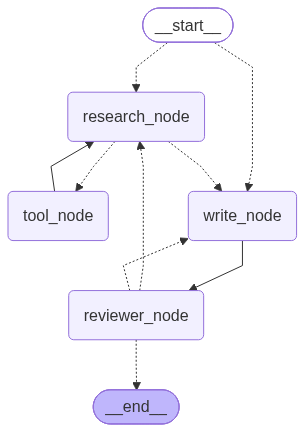

In [15]:
builder = StateGraph(OverAllState)

builder.add_node("research_node", research_node)
builder.add_node("tool_node", ToolNode(tools))
builder.add_node("write_node", write_node)
builder.add_node("reviewer_node", reviewer_node)

builder.add_conditional_edges(
    START,
    supervisor_router,
    {
        "research_node": "research_node",
        "write_node": "write_node",
    }
)

builder.add_conditional_edges(
    "research_node",
    research_router,
    {
        "tool_node": "tool_node",
        "write_node": "write_node",
    }
)
builder.add_edge("tool_node", "research_node")

builder.add_edge("write_node", "reviewer_node")

builder.add_conditional_edges(
    "reviewer_node",
    reviewer_router,
    {
        "research_node": "research_node",
        "write_node": "write_node",
        END: END,
    }
)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
while True: 
    query = input("enter your query")
    if query.strip().lower() in {"exit", "quit"}:
        print("Session Over")
        break 
    
    result = graph.invoke({"user_query": query,
                           "messages_history": [HumanMessage(content=query)]})
    print("\nOutput:", result["output"])